In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import datetime
import math
from scipy import stats

In [2]:
amazon_sales = pd.read_csv("../Datasets/amazon_final.csv")

In [3]:
amazon_sales.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,has_coupon,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,1,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,1,"Audio, Sound & Recording Gear",43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,1,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,0,"Chargers, Adapters & Cables",37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,1,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,0,"Audio, Sound & Recording Gear",10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,0,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,0,Wearables,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,0,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,0,Small Gadget Accessories (Cases & Protectors),0.00


In [4]:
amazon_sales.rename(columns={"category": "product_category"}, inplace=True)
amazon_sales.rename(columns={"rating": "product_rating"}, inplace=True)
amazon_sales.rename(columns={"listed_price": "original_price"}, inplace=True)
amazon_sales.rename(columns={"current/discounted_price": "discounted_price"}, inplace=True)
amazon_sales.rename(columns={"bought_in_last_month": "purchased_last_month"}, inplace=True)


In [5]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(amazon_sales)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,42675,0,object,8808
1,product_rating,41651,1024,float64,32
2,total_reviews,41651,1024,float64,4414
3,purchased_last_month,32164,10511,float64,30
4,discounted_price,40613,2062,float64,3559
5,original_price,40613,2062,float64,3152
6,is_best_seller,42675,0,object,12
7,is_sponsored,42675,0,object,2
8,coupon,42675,0,object,42
9,buy_box_availability,42675,0,int64,2


## 1. Preparación del dataset

### Voy a eliminar las columnas que considero que no me ofrecen valor para el estudio estadístico

In [6]:
# amazon_sales.drop(columns=['data_collected_at', 'delivery_date', 'product_image_url', 'product_page_url'], inplace=True)
# info = info_df(amazon_sales)
# info

In [7]:
amazon_sales.is_best_seller.value_counts()

is_best_seller
No Badge             40814
Amazon's               744
Limited time deal      409
Best Seller            275
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64

In [8]:
amazon_sales.product_category.value_counts()

product_category
Computer Peripherals                             3517
Office Supplies, Ink & Toner                     3470
Audio, Sound & Recording Gear                    3413
PC Components                                    3280
Protection Plans                                 3068
TV & Video Displays                              2891
Wearables                                        2890
Cameras & Photography                            2871
Power & Batteries                                2767
Laptops                                          2611
Chargers, Adapters & Cables                      2494
Small Gadget Accessories (Cases & Protectors)    2405
Storage & Memory Cards                           1993
Printers & Scanners (Hardware)                    936
Other Electronics                                 903
Mobile Cell Phones & Smartphones                  870
Video Game Consoles & Virtual Reality             694
Smart Home & Security                             559
Networking 

### De cara a un análisis estadístico de características de productos, me conviene hacerlo por categorías, me quedaré con la categoría (PC Components: productos relacionados)

# OBJETIVO:

### Lo que pretendo estudiar en este proyecto final son las características de ciertos productos de amazon y como estas influyen en el precio y entre ellas mismas.

# 1. Gráficas sobre las variables relevantes individuales.
- Laptops ( Categoría de "Laptops", productos relacionados)

Haré uso de gráficas aprendidas en la asignatura de Data Vizualitation

- Graficaré las características que me parecen más relevantes en la elección del precio de los productos

C:\Users\admin\AppData\Local\Temp\ipykernel_10740\1280316578.py:86: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



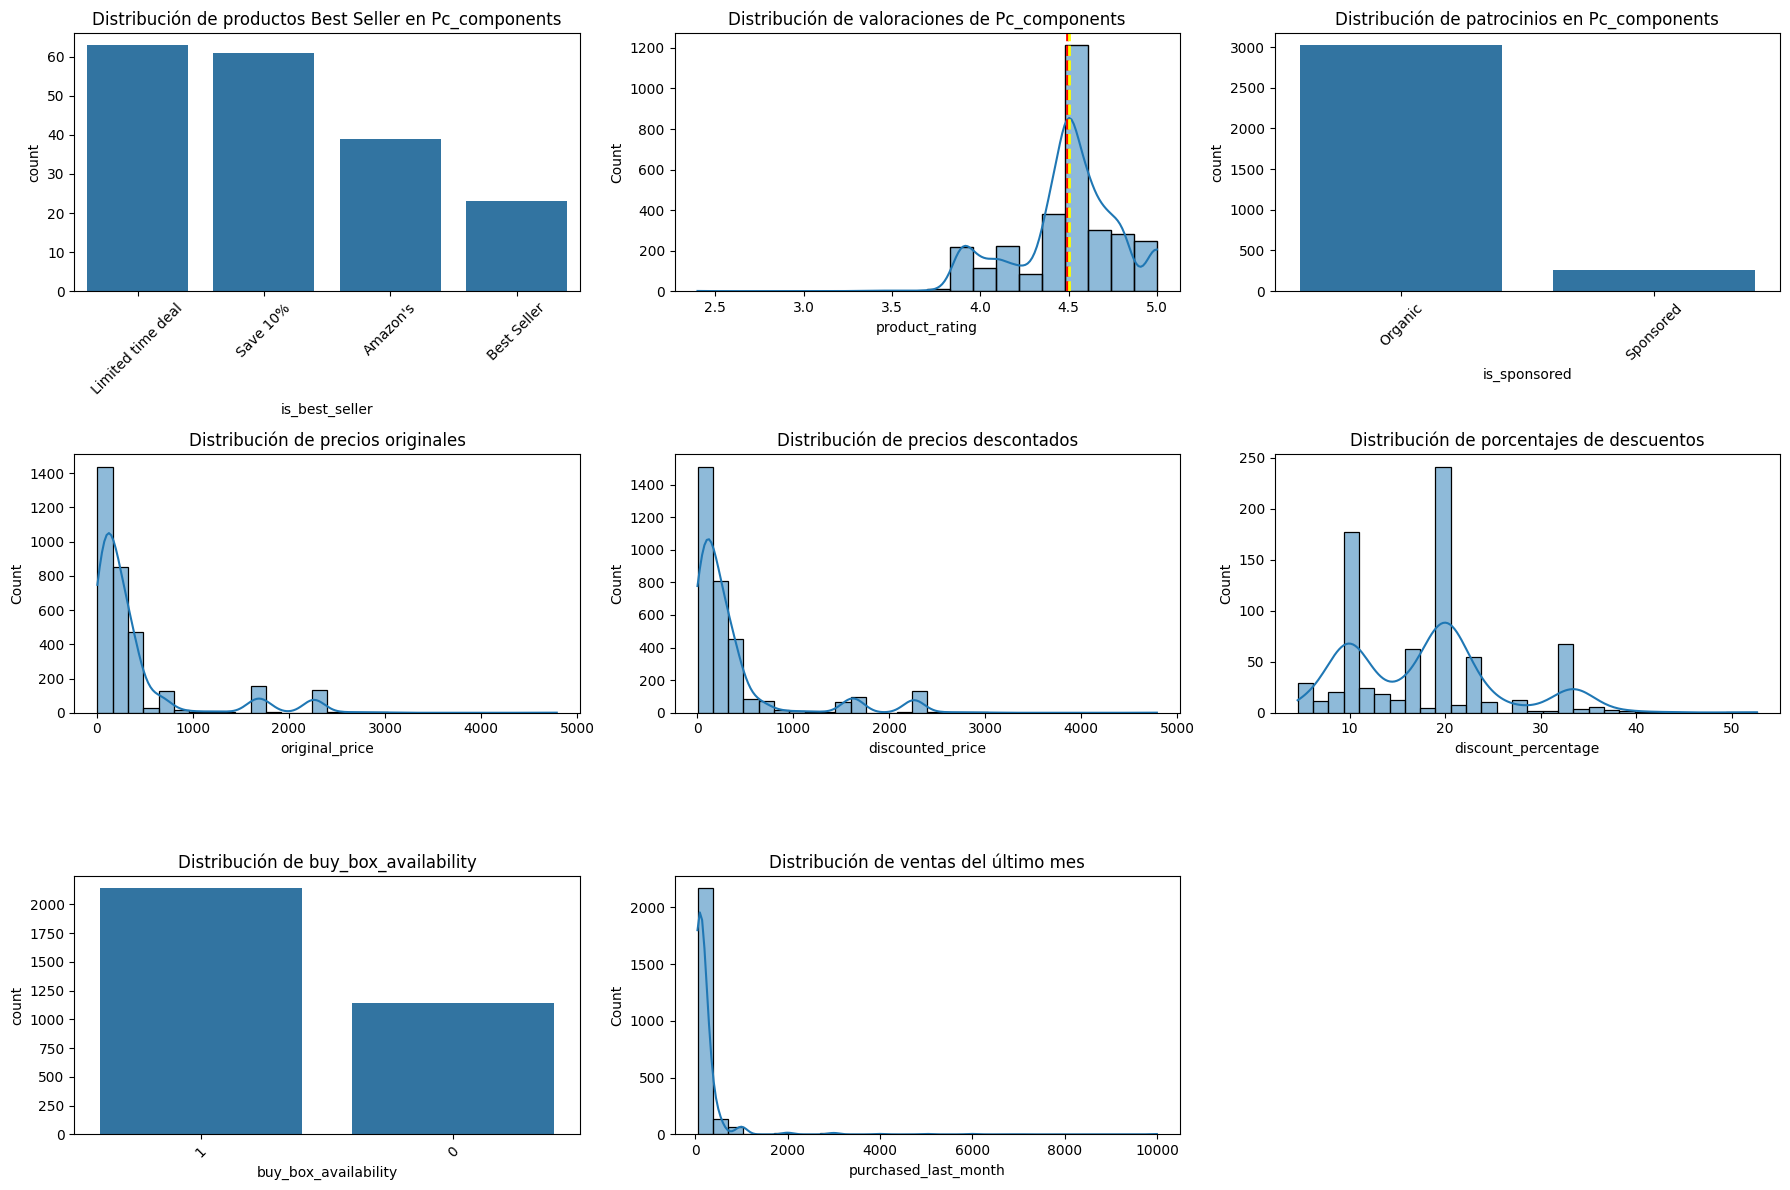

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Subsets
Pc_components = amazon_sales[amazon_sales.product_category == 'PC Components']

pc_components_sin_NoBadge = Pc_components[Pc_components['is_best_seller'] != 'No Badge']


# FIGURA DE 3 FILAS X 3 COLUMNAS
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Distribución de los valores de best seller
ax = axes[0][0]
sns.countplot(
    data=pc_components_sin_NoBadge,
    x='is_best_seller',
    order=pc_components_sin_NoBadge['is_best_seller'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de productos Best Seller en Pc_components')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# Distribución de las valoraciones de los Pc_components
ax = axes[0][1]
sns.histplot(
    Pc_components['product_rating'].dropna(),
    bins=20, kde=True, ax=ax
)
valoracion_media = Pc_components.product_rating.mean()
ax.axvline(valoracion_media,color='red', linestyle='--', linewidth=2, label=f'Media: {valoracion_media:.2f}')
valoracion_mediana = Pc_components.product_rating.median()
ax.axvline(valoracion_mediana,color='yellow', linestyle='--', linewidth=2, label=f'Media: {valoracion_mediana:.2f}')
ax.set_title('Distribución de valoraciones de Pc_components')
ax.set_visible(True)

# -----------------------------------------------------------
# GRAFICA 3 (OCULTA)
# -----------------------------------------------------------
ax = axes[0][2]
sns.countplot(
    data=Pc_components,
    x='is_sponsored',
    order=pc_components_sin_NoBadge['is_sponsored'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de patrocinios en Pc_components')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# -----------------------------------------------------------
# GRAFICA 4 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][0]
sns.histplot(
    Pc_components['original_price'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios originales')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 5 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][1]
sns.histplot(
    Pc_components['discounted_price'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios descontados')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 6 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][2]
sns.histplot(
    Pc_components[Pc_components['discount_percentage'] > 0].discount_percentage.dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de porcentajes de descuentos')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 7 (OCULTA)
# -----------------------------------------------------------
ax = axes[2][0]
Pc_components.buy_box_availability = Pc_components.buy_box_availability.fillna('No')
sns.countplot(
    data=Pc_components,
    x='buy_box_availability',
    order=Pc_components.buy_box_availability.value_counts().index,
    ax=ax
)
ax.set_title('Distribución de buy_box_availability')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

ax = axes[2][1]
sns.histplot(
    Pc_components['purchased_last_month'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de ventas del último mes')
ax.set_visible(True)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()


- Distribución de productos Best Seller: He mostrado la gráfica sin el valor "No Badge" ya que en comparación, el resto de valores se quedaban sin representación. No_badge representa a 8350 productos, sin tenerlo en cuenta, vemos que la etiqueta de productos con la etiqueta Amazon's representa el grupo más poblado, por detrás tenemos los que tienen la etiqueta de tiempo limitado, etiqueta de más vendido y etiquetas de descuendos. Más tarde, analizaré como estas etiquetas influyen al precio

- Distribución de las valoraciones de los productos: esta distribucion nos permite ver como la media de los productos tienen un 4.33 de media en valoraciones, además, vemos como en general los productos de la categoría Laptops están valorados por encima del 4.4 y vemos pocos valores muy bajos

- Distribución de patrocinios: Se observa como la mayoría de productos, no están patrocinados. Más tarde comprobaré cómo de significativo es que esén patrocinados

- Distribución de precios: Se puede apreciar como la mayoría de productos se encuentran en el rango de de 0-1000€, a continuación veré el BoxPlot para ver como se organizan los datos y ver los outliers mejor.

- Distribución de porcentajes de descuentos: Vemos algunos al 75% de descuento aproximadamente y otros por encima del 50% sin embargo, la distribución se reparte mayormente entre el 5% y el 50% de descuento





# 2. OUTLIERS Y RELACIONES ENTRE VARIABLES

Realizando las gráficas de las variables individuales ya he tenido indicios de cuales son los outliers de cada una, de hecho he tenido que filtrar algunas distribuciones para eliminar los outliers de ellas, a continuación los analizaré detalladamente

In [ ]:
import plotly.express as px
fig = px.box(Pc_components, x="product_rating", y='is_sponsored',width=1000, height=500)
fig.show()

In [45]:
Pc_components.is_sponsored.value_counts()

is_sponsored
Organic      3024
Sponsored     256
Name: count, dtype: int64

- Product rating: En el histograma he apreciado una serie de outliers, en esta ocasión he querido mostrar, además a qué tipo de producto, si patrocinado o no, correponden cada valoraciones. Podemos ver como los productos que no están patrocinados, tienen menos outliers pero los que tiene, son mucho más bajos, que los outliers de aquellos productos patrocinados. Más adelante estudiaré la relación entre variables, pero puedo ir viendo un poco la relación entre las valoraciones y el patrocinio del producto.

In [11]:
import plotly.express as px
fig = px.box(Pc_components, x="original_price", y='is_sponsored',width=1000, height=500)
fig.show()

In [46]:
# import plotly.express as px
# fig = px.box(Pc_components, x="original_price", y='buy_box_availability',width=1000, height=500)
# fig.show()

- Original price: Como la categoría Laptops, está formada por todo tipo de productos, no solo portátiles como tal, tenemos outliers altos que corresponden a los portátiles como tal, tenemos muchos productos de bajo coste (cables, pilas...) y por eso tenemos esos outliers

In [13]:
import plotly.express as px
fig = px.box(Pc_components[Pc_components.discount_percentage > 0] , x="discount_percentage",width=1000, height=500)
fig.show()

- discount_percentage:
- Mínimo descuento: 4.55
- El 25% de los productos con descuento tiene un descuento menor o igual a 10.03%
- La mediana es 19.99% de descuento, además la vemos desplazada hacia el Q3, esto nos dice que hay algo de asimetría hacia la izquierda de la distribución y por lo tanto, dentro del rango intercuartílico, los descuentos están más concentrados en la parte alta.
- El 75% de los productos con descuento tiene un descuento menor o igual que 34.70%
- Observamos como hasta el límite superior tenemos más valores que entre el inferior y el Q1, por lo tanto, fuera de la zona intercuartílica hay más descuentos altos.
- Tenemos tres valores considerados outliers (44.47, 50.05, 52.65)

In [14]:
import plotly.express as px
fig = px.box(Pc_components[Pc_components.total_reviews > 10000] , x="total_reviews",width=1000, height=500)
fig.show()

- Observo como el rango intercuartílico se encuentra entre las 10000 y las 45000 Reseñas, tenemos cinco productos 'TopVentas' que pasan de estos límites

In [15]:
import plotly.express as px

fig = px.box(Pc_components, x="purchased_last_month",width=1000, height=500)
fig.update_layout(width=1000,height=500)
fig.show()

In [51]:
import plotly.express as px

fig = px.box(Pc_components, x="purchased_last_month", y='is_sponsored',width=1000, height=500)
fig.update_layout(width=1000,height=500)
fig.show()

In [52]:
import plotly.express as px
fig = px.box(Pc_components[Pc_components.purchased_last_month < 10000], x="purchased_last_month",y='is_sponsored',width=1000, height=500)
fig.show()


- Aquí tenemos datos muy dispersos con un intervalo muy ancho. Por lo tanto he decidido separar entre Patrocinados y Orgánicos para ver la relación con las ventas, además he filtrado los outliers más altos para poder ver la relación en ventas por debajo de 10000
- Se puede observar como los productos Orgánicos tienen muchas más ventas que los patrocinados , esto puede deberse a que los consumidores preferirán calidad a precio , por lo que los productos de gama alta no suelen estar rebajados siendo el más alto 10K comparado con el patrocinado cuyo máximo es 1k.

# 3. TESTS



In [18]:
from tqdm import tqdm
import pandas as pd

def boot(data):
    veces = 10000   # número de medias a generar
    muestra = 300   # tamaño de cada muestra
    medias_rating = []

    for i in tqdm(range(veces)):
        muestra_i = data.sample(muestra, replace=True)   # with replacement
        medias_rating.append(muestra_i.mean())

    df_boot = pd.DataFrame({"medias": medias_rating})
    return df_boot

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

def paint(data):
    plt.figure(figsize=(8,5))
    sns.histplot(data, kde=True, bins=30)
    plt.title("Distribución de medias bootstrap de product_rating")
    plt.xlabel("Media del rating (muestras de tamaño 300)")
    plt.show()

    stats.probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot medias bootstrap product_rating")
    plt.show()

In [20]:
from scipy import stats
# Aplicar el test de Shapiro-Wilk

def test_normalidad(test,grupo):
    stat, p = test(grupo)

    print("Estadístico:", stat)
    print("p-valor:", p)

    if p < 0.05:
        print("Los datos NO siguen una distribución normal.")
    else:
        print("Los datos podrían seguir una distribución normal...o no")

## 3.1 ¿ Existe una diferencia singificativa entre la valoración de los productos patrocinados y los orgánicos ?

### En el estudio de outliers ya he podido comprobar como podría haber diferencias entre las valoraciones de los productos patrocinados y los que no están patrocinados.

## NORMALIDAD DE PRODUCT_RATING

100%|██████████| 10000/10000 [00:01<00:00, 7452.63it/s]


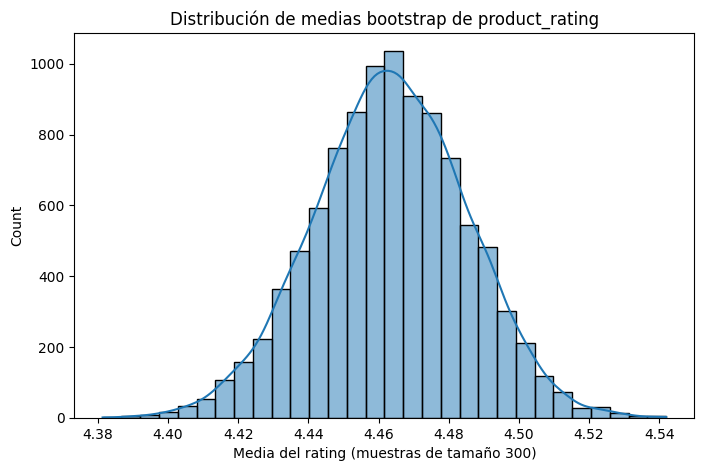

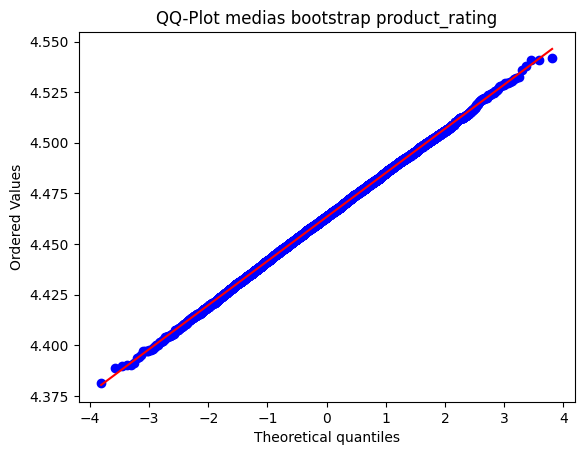

In [21]:
data = Laptops['product_rating'].dropna()

df_boot = boot(data)

paint(df_boot["medias"])

In [22]:
test_normalidad(stats.shapiro,df_boot["medias"])

Estadístico: 0.999767250075499
p-valor: 0.3465229808240263
Los datos podrían seguir una distribución normal...o no


c:\Users\admin\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [23]:
test_normalidad(stats.normaltest,df_boot["medias"])

Estadístico: 2.8812368004182893
p-valor: 0.2367812878000804
Los datos podrían seguir una distribución normal...o no


- Primero estudiaremos las diferencias de sus varianzas con el test de Levene


In [24]:
import numpy as np
from scipy import stats

# Creamos dos grupos con varianzas distintas
grupo1 = Pc_components[Pc_components.is_sponsored == 'Sponsored'].product_rating.dropna()
grupo2 = Pc_components[Pc_components.is_sponsored == 'Organic'].product_rating.dropna()

# Verificamos si las varianzas son realmente diferentes con la prueba de Levene
stat, p_var = stats.levene(grupo1, grupo2)
print(f"Prueba de Levene (varianza): p-value = {p_var:.8f}. Estadístico: {stat:.8f}")

Prueba de Levene (varianza): p-value = 0.00000000. Estadístico: 205.59462502


In [25]:
grupo1.std(), grupo2.std()

(0.09634682365355243, 0.3017344888851017)

- No podemos afirmar que las varianzas sean diferentes (Estadísticamente podrían ser iguales)

- Por lo tanto haré el Test de Mann-Whitney U para estudiar la diferencia de sus medias. Usaré este test ya que no puedo asumir normalidad de los datos de las valoraciones

C:\Users\admin\AppData\Local\Temp\ipykernel_10740\626821043.py:10: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



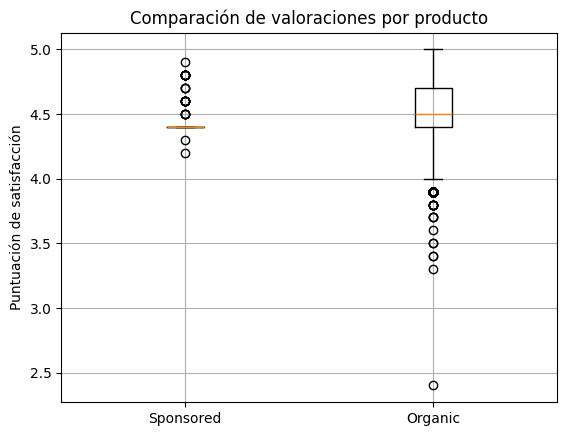

Estadístico U: 218140.50
Valor p: 0.0000
Hay una diferencia significativa en la valoración de los productos.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Simulamos dos grupos con distribuciones diferentes
grupo1 = Pc_components[Pc_components.is_sponsored == 'Sponsored'].product_rating.dropna()
grupo2 = Pc_components[Pc_components.is_sponsored == 'Organic'].product_rating.dropna()

# Gráfico de cajas
plt.boxplot([grupo1, grupo2], labels=["Sponsored", "Organic"])
plt.title("Comparación de valoraciones por producto")
plt.ylabel("Puntuación de satisfacción")
plt.grid(True)
plt.show()

# Prueba de Mann-Whitney U
stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p:.4f}")

if p < 0.05:
    print("Hay una diferencia significativa en la valoración de los productos.")
else:
    print("No se detecta una diferencia significativa.")

- Podemos afirmar que las valoraciones sean significativamente diferentes dependiendo del producto patrocinado o no

## 3.2 ¿ Existe una diferencia significativa entre las ventas de los productos patrocinados y los que no ?

In [27]:
Pc_components[Pc_components.is_sponsored == 'Sponsored'].purchased_last_month.mean(), Pc_components[Pc_components.is_sponsored == 'Organic'].purchased_last_month.mean()

(264.2857142857143, 231.4506044185077)

### Parece que los patrocinados se han vendido un poco más en el último mes

## NORMALIDAD DE PURCHASED_LAST_MONTH

100%|██████████| 10000/10000 [00:01<00:00, 7508.02it/s]


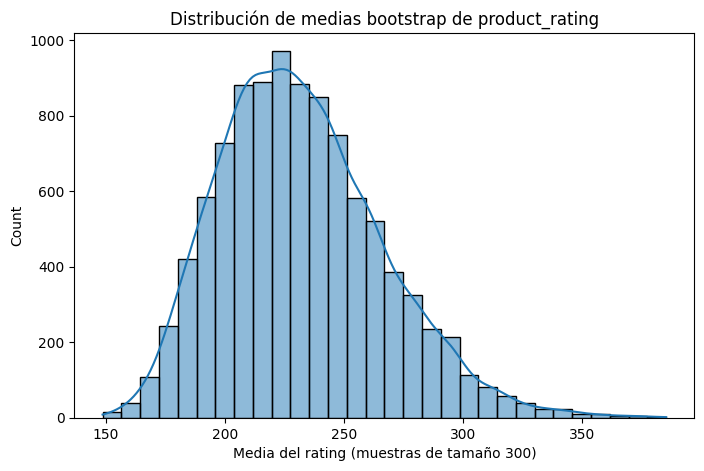

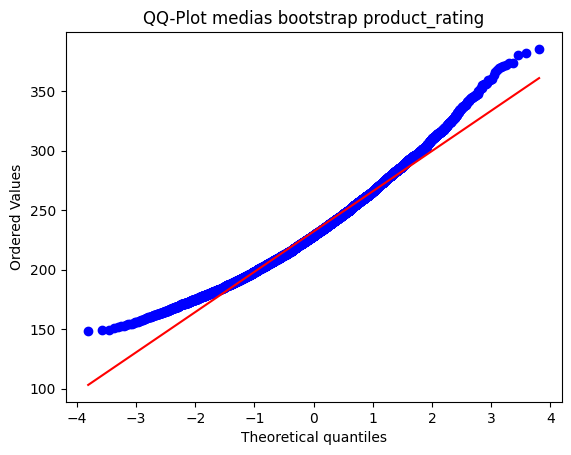

In [28]:
data = Pc_components['purchased_last_month'].dropna()

df_boot = boot(data)

paint(df_boot["medias"])

In [29]:
test_normalidad(stats.shapiro,df_boot["medias"])

Estadístico: 0.9807447925827035
p-valor: 1.2845928594326151e-34
Los datos NO siguen una distribución normal.


c:\Users\admin\Documents\GitHub\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [30]:
test_normalidad(stats.normaltest,df_boot["medias"])

Estadístico: 523.1886762126013
p-valor: 2.4604948666560488e-114
Los datos NO siguen una distribución normal.


### - No puedo asumir su normalidad

## VARIANZAS

In [31]:
Pc_components[Pc_components.is_sponsored == 'Sponsored'].purchased_last_month.dropna().std(), Pc_components[Pc_components.is_sponsored == 'Organic'].purchased_last_month.dropna().std()

(216.99749327564155, 589.4186332547944)

In [32]:
import numpy as np
from scipy import stats

# Creamos dos grupos con varianzas distintas

grupo1 = Pc_components[Pc_components.is_sponsored == 'Sponsored'].purchased_last_month.dropna()
grupo2 = Pc_components[Pc_components.is_sponsored == 'Organic'].purchased_last_month.dropna()

# Verificamos si las varianzas son realmente diferentes con la prueba de Levene
stat, p_var = stats.levene(grupo1, grupo2)
print(f"Prueba de Levene (varianza): p-value = {p_var:.4f}. Estadístico: {stat:.4f}")

Prueba de Levene (varianza): p-value = 0.5872. Estadístico: 0.2949


### Lo que nos dice la prueba de Levene es que no hay evidencia suficiente para rechazar la igualdad de varianzas

- Por lo tanto aplicaré el test de Mann Whitney, usado como la prueba t de Student para variables de varianza desigual

In [53]:
# Prueba no paramétrica (Mann-Whitney)
u_stat, p_mw = stats.mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print("\nCOMPARACIÓN:")
print(f"Mann-Whitney U - p-valor: {p_mw:.4f}")


COMPARACIÓN:
Mann-Whitney U - p-valor: 0.0016


### Rechazamos hipotesis


## 3.3 ¿Existe alguna relación entre el patrocinio (o no) y la etiqueta de best_seller?

- ### Dividiré entre aquellos que tienen etiqueta de best seller y los que no

In [34]:
Pc_components.is_best_seller.value_counts()

is_best_seller
No Badge             3094
Limited time deal      63
Save 10%               61
Amazon's               39
Best Seller            23
Name: count, dtype: int64

In [35]:
len(Pc_components[Pc_components.is_best_seller != 'No Badge'])

186

In [36]:
Pc_components[['is_best_seller', 'is_sponsored']]

,is_best_seller,is_sponsored
32,No Badge,Sponsored
53,Best Seller,Organic
59,No Badge,Sponsored
78,Best Seller,Organic
116,No Badge,Sponsored
...,...,...
42645,Save 10%,Organic
42653,Limited time deal,Organic
42661,No Badge,Organic
42663,No Badge,Organic


In [37]:
tabla_observada = pd.crosstab(Pc_components["is_best_seller"], Pc_components["is_sponsored"])
n = tabla_observada.sum().sum()
print("Total Elementos", n)
tabla_observada

Total Elementos 3280


is_sponsored,Organic,Sponsored
is_best_seller,,
Amazon's,36,3
Best Seller,23,0
Limited time deal,63,0
No Badge,2841,253
Save 10%,61,0


In [38]:
print(Pc_components["is_best_seller"].unique())
Pc_components["is_best_seller"].value_counts(normalize=True)

['No Badge' 'Best Seller' "Amazon's" 'Limited time deal' 'Save 10%']


is_best_seller
No Badge             0.943293
Limited time deal    0.019207
Save 10%             0.018598
Amazon's             0.011890
Best Seller          0.007012
Name: proportion, dtype: float64

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Ver la tabla de frecuencias observada
tabla_observada = pd.crosstab(Pc_components["is_best_seller"], Pc_components["is_sponsored"])
print("Tabla de Frecuencias Observada:\n", tabla_observada)

# Calcular el test de Chi-cuadrado
chi2, p, dof, tabla_esperada = chi2_contingency(tabla_observada)

# Mostrar resultados
print(f"Valor p: {p}")

# Interpretación del resultado
alpha = 0.05
if p < alpha:
    print("\nRechazamos la hipótesis nula: Existe una asociación significativa entre la etiqueta de best_seller y el patrocinio")
else:
    print("\nNo se puede rechazar la hipótesis nula: No se encontró asociación significativa entre la etiqueta de best_seller y el patrocinio")


Tabla de Frecuencias Observada:
 is_sponsored       Organic  Sponsored
is_best_seller                       
Amazon's                36          3
Best Seller             23          0
Limited time deal       63          0
No Badge              2841        253
Save 10%                61          0
Valor p: 0.011077588590967274

Rechazamos la hipótesis nula: Existe una asociación significativa entre la etiqueta de best_seller y el patrocinio


### El test χ² indica una asociación altamente significativa entre ser Sponsored y la presencia de etiquetas promocionales o de calidad (Amazon’s Choice, Best Seller, Save %...).

### En otras palabras, la distribución de etiquetas es distinta entre Sponsored y Organic.
### Los productos patrocinados presentan una mayor proporción de badges positivos (Amazon’s Choice, Best Seller, Save%), mientras que los productos orgánicos tienden a no tener ningún badge.

# 4. CORRELACIONES

### Estudiando los outliers también grafiqué ciertas relaciones entre pares de variables

In [40]:
import plotly.express as px
fig = px.scatter(Pc_components, x='product_rating', y='original_price', title="Scatter Plot con Plotly")
fig.show()
df = Pc_components.groupby('product_rating')['original_price'].mean()
fig = px.scatter(df, x=df.index, y=df.values, title="Scatter Plot con Plotly")
fig.show()

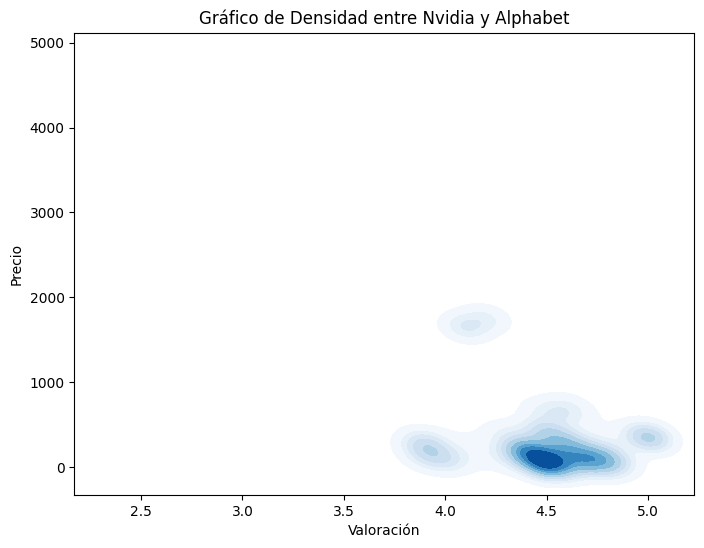

In [41]:
import seaborn as sns

# Gráfico de densidad para ver la relación entre BBVA y Santander
plt.figure(figsize=(8, 6))
sns.kdeplot(x='product_rating', y='original_price', data=Pc_components, fill=True, cmap="Blues")
plt.title('Gráfico de Densidad entre Nvidia y Alphabet')
plt.xlabel('Valoración')
plt.ylabel('Precio')
plt.show()

### Parece que hay muchos productos que no superan los 1000 €

In [42]:
v = Pc_components.groupby(['is_sponsored', 'is_best_seller'])['purchased_last_month'].sum().reset_index()
v.pivot(index='is_best_seller', columns='is_sponsored', values='purchased_last_month')

is_sponsored,Organic,Sponsored
is_best_seller,,
Amazon's,8300.0,1000.0
Best Seller,69700.0,NaN
Limited time deal,3150.0,NaN
No Badge,474100.0,2700.0
Save 10%,0.0,NaN


- ### Ventas en el último mes dependiendo de su etiqueta de best_seller y sponsored

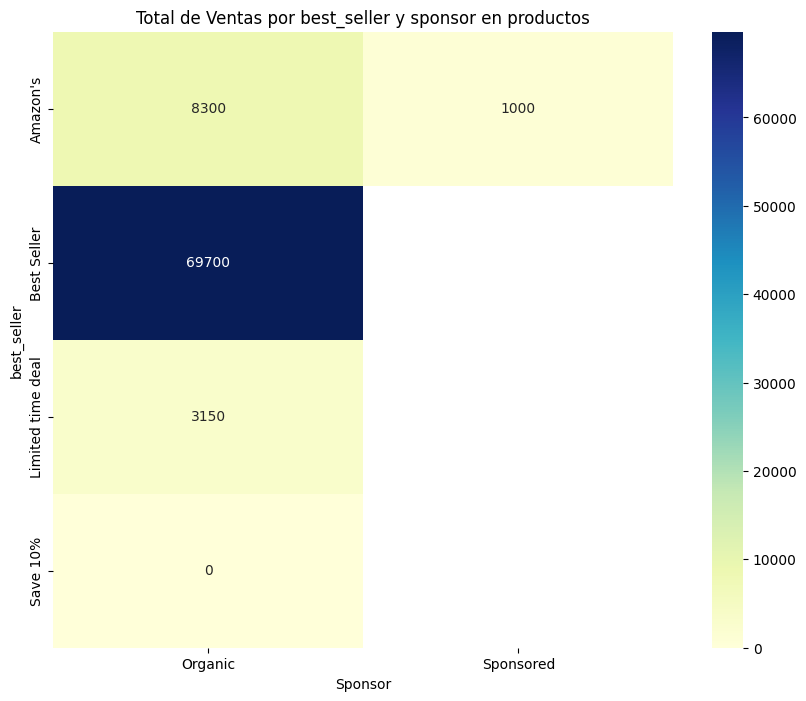

In [43]:
ventas_por_sponsored = pc_components_sin_NoBadge.groupby(['is_sponsored', 'is_best_seller'])['purchased_last_month'].sum().reset_index()
# ventas_por_sponsored = ventas_por_sponsored.sort_values('N.Mes')

# Formato ancho
ventas_pivot = ventas_por_sponsored.pivot(index='is_best_seller', columns='is_sponsored', values='purchased_last_month')
# ventas_pivot.columns = ventas_por_sponsored.drop_duplicates(subset=['N.Mes'])['MES']

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(ventas_pivot, annot=True, fmt=".0f", cmap="YlGnBu")

# Añadir título y etiquetas
plt.title('Total de Ventas por best_seller y sponsor en productos')
plt.xlabel('Sponsor')
plt.ylabel('best_seller')
plt.show()

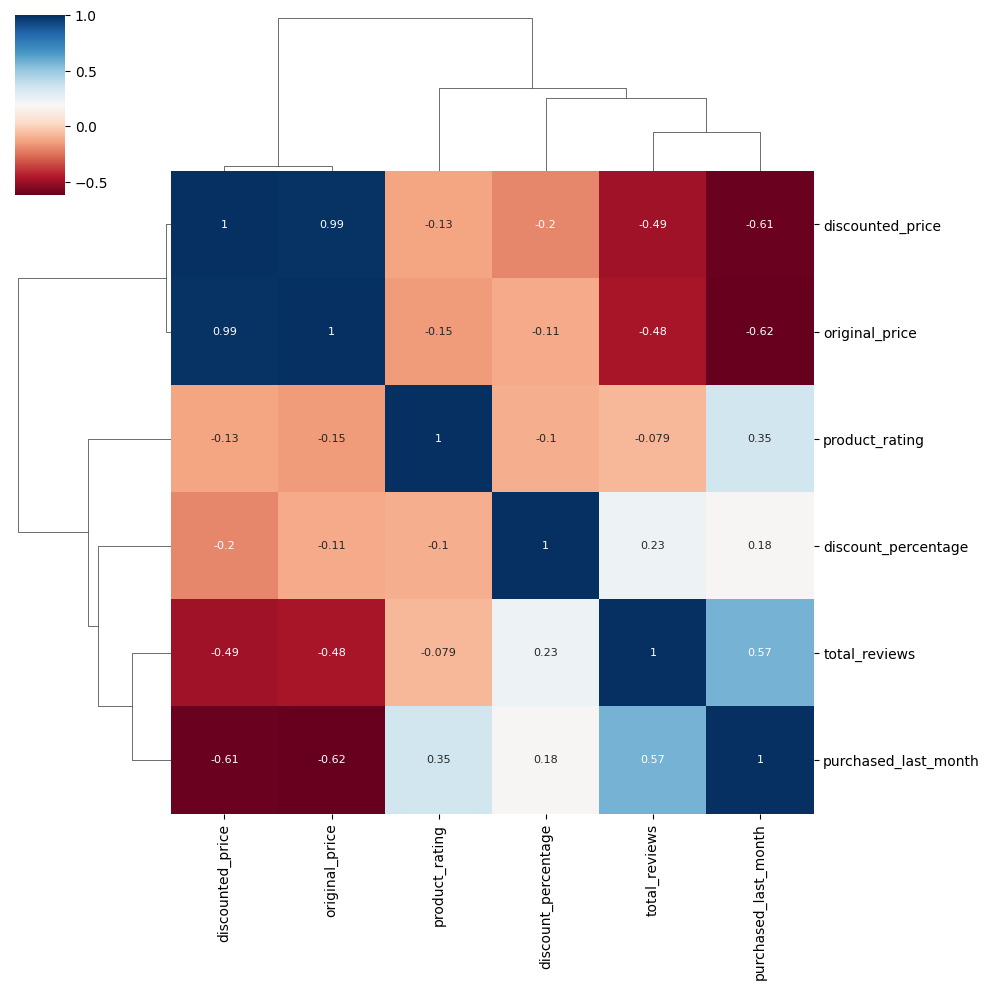

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(Pc_components[['product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']].corr(method='spearman'),
                   method = 'complete',
                   cmap   = 'RdBu',
                   annot  = True,
                   annot_kws = {'size': 8})

- total_reviews y ventas en el último mes: Podemos apreciar una correlación positiva entre el número de reviews y las ventas en el último mes, esto tiene mucho sentido ya que a más ventas, más personas pondrán una review al producto.
- discounted price y original price: Son prácticamente iguales o directamente proporcionales
- discount_percentage y discounted_price : cuanto más alto es el porcentaje de descuento, más bajo es el precio descontado
- original price/discounted_price y product_rating: a más alto el precio, menor tenderá a ser la valoración del producto